<a href="https://colab.research.google.com/github/TaiwoOlaniyiToheeb/multivariate_analysis/blob/main/marketing_sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Multivariate OLS Regression — Marketing ROI Analysis
---
**Objective:** Model the combined effect of TV spend tier, Radio spend, Social Media spend, and Influencer type on Sales using Ordinary Least Squares (OLS) multiple regression. Identify which channels deliver the strongest incremental ROI and provide evidence-based budget recommendations.

**Key upgrades over simple linear regression:**
- All numeric predictors (Radio, Social Media) included alongside TV
- Categorical variables (TV tier, Influencer type) one-hot encoded
- Variance Inflation Factor (VIF) test for multicollinearity
- Partial regression plots per predictor
- Coefficient comparison chart for business storytelling

**Deliverables:**
- Cleaned, analysis-ready dataset
- EDA with full correlation and pairwise analysis
- Multivariate OLS model with complete assumption diagnostics
- Business interpretation and channel-level ROI recommendation

> **Author:** Olaniyi | **Tool:** Python + statsmodels | **Method:** Multivariate OLS (Ordinary Least Squares)


## 1. Import Libraries
We load the standard data science stack plus `variance_inflation_factor` for multicollinearity diagnostics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_partregress_grid
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load & Explore the Dataset
We load the dataset and inspect its structure. Note that `TV` and `Influencer` are **categorical** variables, while `Radio` and `Social_Media` are continuous.


In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────

filepath = "/content/drive/MyDrive/colab files/marketing_sales_data.csv"
df = pd.read_csv(filepath)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)


Dataset shape: 572 rows x 5 columns


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377
5,Low,5.561586,3.530209,Nano,39.992087
6,Medium,13.951808,4.477142,Micro,147.150178
7,Medium,28.352592,4.695376,Mega,229.141912
8,Medium,15.322175,4.379750,Macro,222.696768
9,High,26.914287,6.074165,Mega,322.466797


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [6]:
df.describe(include='all').round(2)


,TV,Radio,Social Media,Influencer,Sales
count,572,572.00,572.00,572,572.00
unique,3,NaN,NaN,4,NaN
top,Medium,NaN,NaN,Nano,NaN
freq,205,NaN,NaN,157,NaN
mean,NaN,17.52,3.33,NaN,189.30
std,NaN,9.29,2.24,NaN,89.87
min,NaN,0.11,0.00,NaN,33.51
25%,NaN,10.70,1.59,NaN,118.72
50%,NaN,17.15,3.15,NaN,184.01
75%,NaN,24.61,4.73,NaN,264.50


In [7]:
# Check category levels
print("TV tiers     :", df['TV'].unique())
print("Influencer   :", df['Influencer'].unique())


TV tiers     : ['Low' 'High' 'Medium']
Influencer   : ['Micro' 'Mega' 'Nano' 'Macro']


## 3. Handle Missing Values
We report any gaps and apply listwise deletion where missingness is low (<3% per column).

In [8]:
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Missing Count": missing, "Missing (%)": pct_missing}))
print(f"\nTotal missing cells: {missing.sum()}")

df_clean = df.dropna().reset_index(drop=True)
print(f"\nRows before : {len(df)}")
print(f"Rows after  : {len(df_clean)}")
print(f"Removed     : {len(df) - len(df_clean)}")
df = df_clean


              Missing Count  Missing (%)
TV                        0          0.0
Radio                     0          0.0
Social Media              0          0.0
Influencer                0          0.0
Sales                     0          0.0

Total missing cells: 0

Rows before : 572
Rows after  : 572
Removed     : 0


## 4. Feature Engineering — Encoding Categorical Variables
OLS requires numeric inputs. We one-hot encode `TV` (Low/Medium/High) and `Influencer` (Nano/Micro/Macro/Mega), dropping one level each as the **reference category** to avoid the dummy variable trap.

- **TV reference:** Low  
- **Influencer reference:** Nano


In [9]:
# One-hot encode TV and Influencer; drop_first avoids perfect multicollinearity
tv_dummies  = pd.get_dummies(df['TV'],         prefix='TV',         drop_first=True).astype(int)
inf_dummies = pd.get_dummies(df['Influencer'], prefix='Influencer', drop_first=True).astype(int)

# Build modelling dataframe
df_model = pd.concat([
    df[['Radio', 'Social Media', 'Sales']],
    tv_dummies,
    inf_dummies
], axis=1)

print("Encoded columns:", df_model.columns.tolist())
df_model.head()


Encoded columns: ['Radio', 'Social Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,1,0,0,1,0
1,7.756876,2.572287,67.574904,1,0,1,0,0
2,20.348988,1.227180,272.250108,0,0,0,1,0
3,20.108487,2.728374,195.102176,0,1,1,0,0
4,31.653200,7.776978,273.960377,0,0,0,0,1


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of Continuous Variables

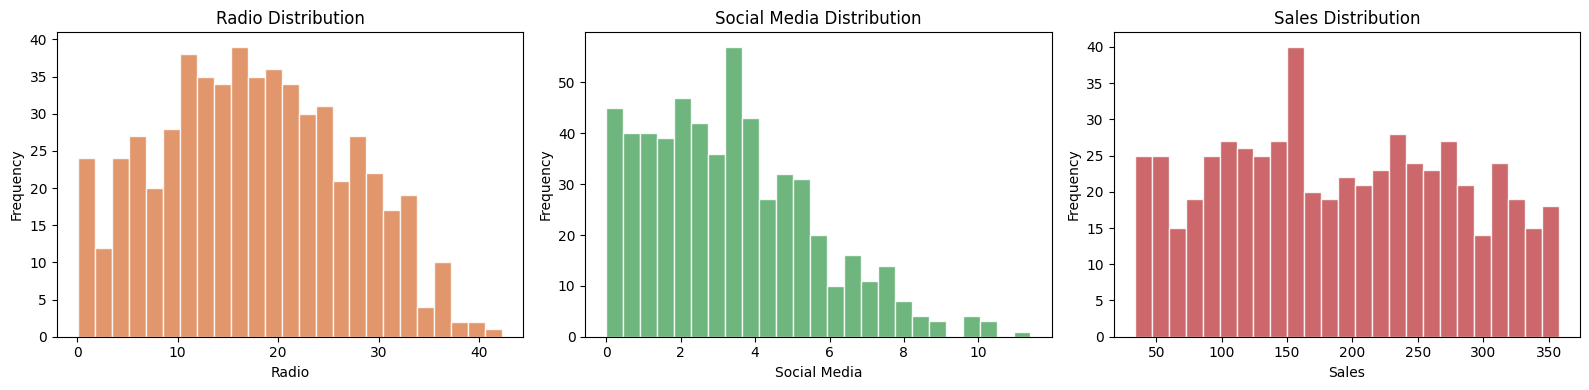

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cont_cols = ['Radio', 'Social Media', 'Sales']
colors    = ['#DD8452', '#55A868', '#C44E52']

for ax, col, clr in zip(axes, cont_cols, colors):
    ax.hist(df[col], bins=25, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("fig_distributions.png", bbox_inches="tight", dpi=150)
plt.show()


### 5.2 Sales by TV Tier and Influencer Type

/tmp/ipykernel_894/1679063900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TV', y='Sales', order=tier_order, palette='Blues',
/tmp/ipykernel_894/1679063900.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Influencer', y='Sales', order=inf_order, palette='Greens',


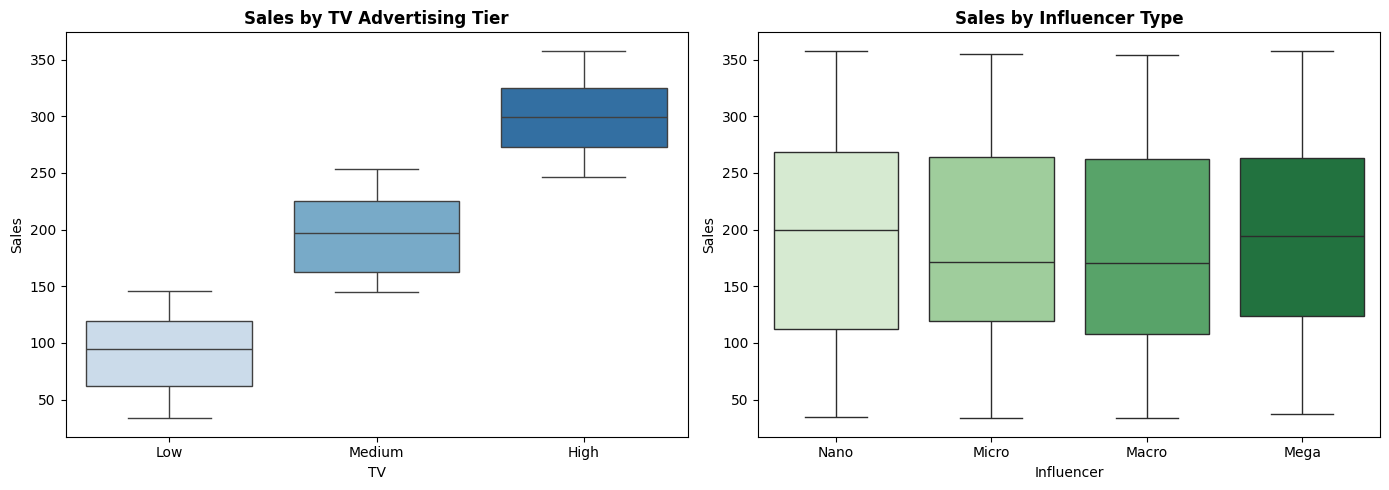

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TV tier vs Sales
tier_order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='TV', y='Sales', order=tier_order, palette='Blues',
            ax=axes[0])
axes[0].set_title('Sales by TV Advertising Tier', fontweight='bold')

# Influencer type vs Sales
inf_order = ['Nano', 'Micro', 'Macro', 'Mega']
sns.boxplot(data=df, x='Influencer', y='Sales', order=inf_order, palette='Greens',
            ax=axes[1])
axes[1].set_title('Sales by Influencer Type', fontweight='bold')

plt.tight_layout()
plt.savefig("fig_category_boxplots.png", bbox_inches="tight", dpi=150)
plt.show()


### 5.3 Scatter Matrix — Continuous Predictors vs Sales

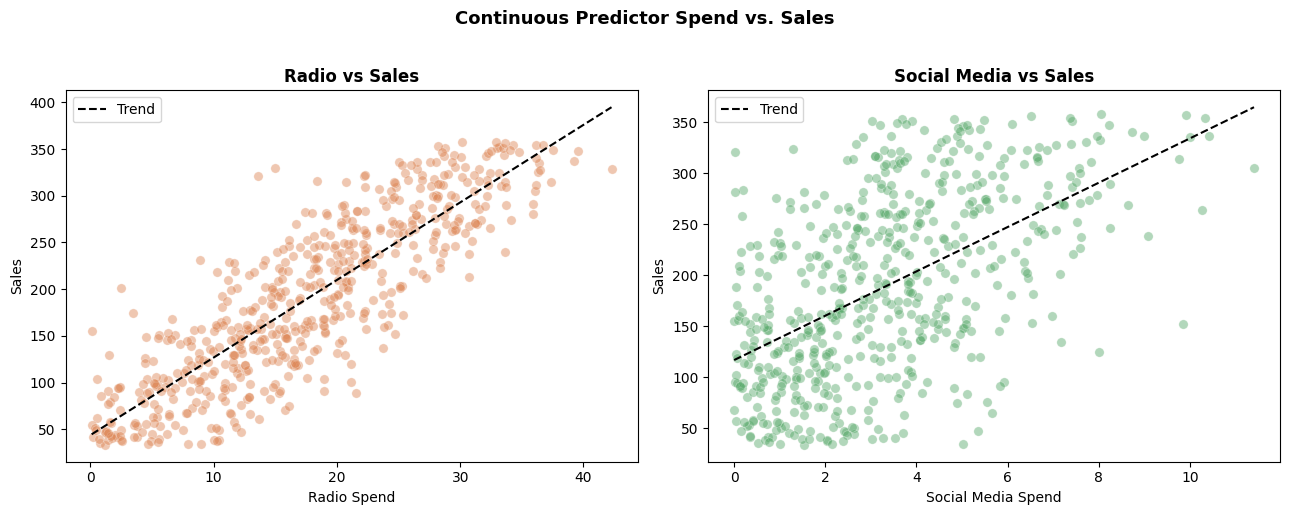

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pairs  = [('Radio', '#DD8452'), ('Social Media', '#55A868')]

for ax, (ch, clr) in zip(axes, pairs):
    ax.scatter(df[ch], df['Sales'], alpha=0.45, color=clr,
               edgecolors='white', linewidths=0.4, s=45)
    m, b = np.polyfit(df[ch], df['Sales'], 1)
    xl = np.linspace(df[ch].min(), df[ch].max(), 200)
    ax.plot(xl, m*xl + b, color='black', linewidth=1.5, linestyle='--', label='Trend')
    ax.set_xlabel(f'{ch} Spend')
    ax.set_ylabel('Sales')
    ax.set_title(f'{ch} vs Sales', fontweight='bold')
    ax.legend()

plt.suptitle('Continuous Predictor Spend vs. Sales', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("fig_scatter_channels.png", bbox_inches="tight", dpi=150)
plt.show()


### 5.4 Pearson Correlation Matrix (Numeric Features)

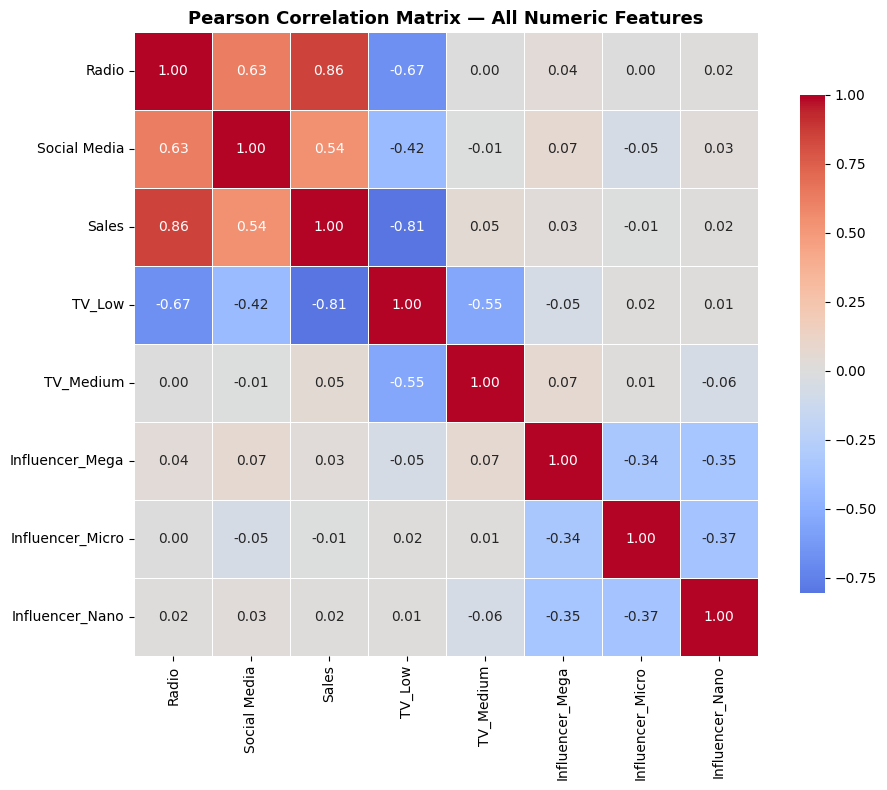


Correlation with Sales (ranked):
  Radio                     +0.8580  ██████████████████████████████████
  Social Media              +0.5420  █████████████████████
  TV_Medium                 +0.0504  ██
  Influencer_Mega           +0.0324  █
  Influencer_Nano           +0.0177  
  Influencer_Micro          -0.0065  
  TV_Low                    -0.8059  ████████████████████████████████


In [13]:
corr = df_model.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson Correlation Matrix — All Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

# Rank by correlation with Sales
sales_corr = corr['Sales'].drop('Sales').sort_values(ascending=False)
print("\nCorrelation with Sales (ranked):")
for feat, val in sales_corr.items():
    bar = '█' * int(abs(val) * 40)
    print(f"  {feat:<25} {val:+.4f}  {bar}")


## 6. Build the Multivariate OLS Regression Model
We regress Sales on all encoded predictors simultaneously.

**Model equation:**  
`Sales = β₀ + β₁·Radio + β₂·Social_Media + β₃·TV_High + β₄·TV_Medium + β₅·Influencer_Macro + β₆·Influencer_Mega + β₇·Influencer_Micro + ε`


In [14]:
# Separate features and target
feature_cols = [c for c in df_model.columns if c != 'Sales']
X = df_model[feature_cols]
y = df_model['Sales']

X_const = sm.add_constant(X)   # Add intercept (β₀)

# Fit OLS
model = sm.OLS(y, X_const).fit()

# Store predictions and residuals
predictions = model.predict(X_const)
residuals   = y - predictions

print("Multivariate OLS model fitted successfully.")
print(f"Observations  : {int(model.nobs)}")
print(f"Predictors    : {len(feature_cols)}")
print(f"R-squared     : {model.rsquared:.4f}")
print(f"Adj R-squared : {model.rsquared_adj:.4f}")
print(f"F-statistic   : {model.fvalue:.2f}  (p = {model.f_pvalue:.4e})")


Multivariate OLS model fitted successfully.
Observations  : 572
Predictors    : 7
R-squared     : 0.9042
Adj R-squared : 0.9030
F-statistic   : 760.38  (p = 1.8171e-282)


In [15]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        06:15:12   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

## 7. Multicollinearity Check — Variance Inflation Factor (VIF)
VIF measures how much a predictor's variance is inflated by correlation with other predictors.  
**Rule of thumb:** VIF < 5 → acceptable | VIF 5–10 → moderate | VIF > 10 → problematic.


In [16]:
vif_data = pd.DataFrame({
    'Feature': X_const.columns,
    'VIF'    : [variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Status'] = vif_data['VIF'].apply(
    lambda v: '✅ OK' if v < 5 else ('⚠️ Moderate' if v < 10 else '❌ High'))

print(vif_data.to_string(index=False))


         Feature  VIF Status
          TV_Low 4.08   ✅ OK
           Radio 3.48   ✅ OK
       TV_Medium 2.23   ✅ OK
    Social Media 1.67   ✅ OK
 Influencer_Nano 1.63   ✅ OK
Influencer_Micro 1.62   ✅ OK
 Influencer_Mega 1.59   ✅ OK


## 8. Model Interpretation
Below we extract each coefficient, its p-value and confidence interval, and translate them into business language.


In [17]:
ci = model.conf_int()

coef_df = pd.DataFrame({
    'Coefficient': model.params,
    'Std Error'  : model.bse,
    'p-value'    : model.pvalues,
    'CI Lower'   : ci[0],
    'CI Upper'   : ci[1],
}).drop('const').round(4)

coef_df['Significant'] = coef_df['p-value'].apply(
    lambda p: '✅ Yes' if p < 0.05 else '❌ No')

print(coef_df.to_string())


                  Coefficient  Std Error  p-value  CI Lower  CI Upper Significant
Radio                  2.9735     0.2352   0.0000    2.5116    3.4355       ✅ Yes
Social Media          -0.1391     0.6761   0.8371   -1.4670    1.1889        ❌ No
TV_Low              -154.5736     4.9494   0.0000 -164.2952 -144.8520       ✅ Yes
TV_Medium            -75.5947     3.6473   0.0000  -82.7586  -68.4307       ✅ Yes
Influencer_Mega        2.4948     3.4620   0.4714   -4.3052    9.2948        ❌ No
Influencer_Micro       2.9391     3.3777   0.3846   -3.6953    9.5735        ❌ No
Influencer_Nano        0.8015     3.3457   0.8107   -5.7699    7.3730        ❌ No


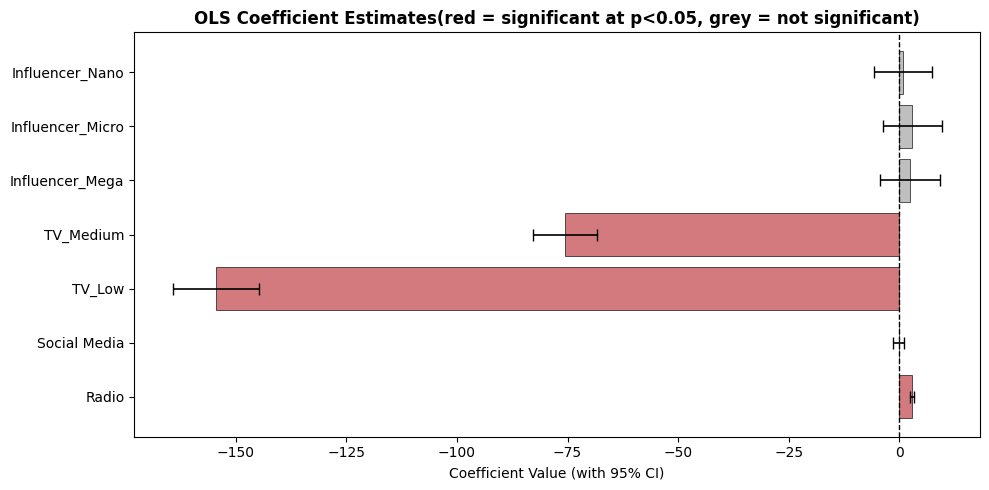

In [18]:
# Coefficient plot
fig, ax = plt.subplots(figsize=(10, 5))
feat_names = coef_df.index.tolist()
coefs      = coef_df['Coefficient']
ci_lo      = coef_df['CI Lower']
ci_hi      = coef_df['CI Upper']
colors_bar = ['#C44E52' if p < 0.05 else '#AAAAAA' for p in coef_df['p-value']]

y_pos = np.arange(len(feat_names))
ax.barh(y_pos, coefs, xerr=[coefs - ci_lo, ci_hi - coefs],
        color=colors_bar, alpha=0.75, edgecolor='black', linewidth=0.6,
        error_kw={'linewidth': 1.2, 'capsize': 4})
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names)
ax.set_xlabel('Coefficient Value (with 95% CI)')
ax.set_title('OLS Coefficient Estimates(red = significant at p<0.05, grey = not significant)',fontweight='bold')
plt.tight_layout()
plt.savefig("fig_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()


## 9. Partial Regression Plots
Partial regression (added-variable) plots show the unique linear relationship between each predictor and Sales **after controlling for all other predictors** — the multivariate equivalent of the single scatter plot.


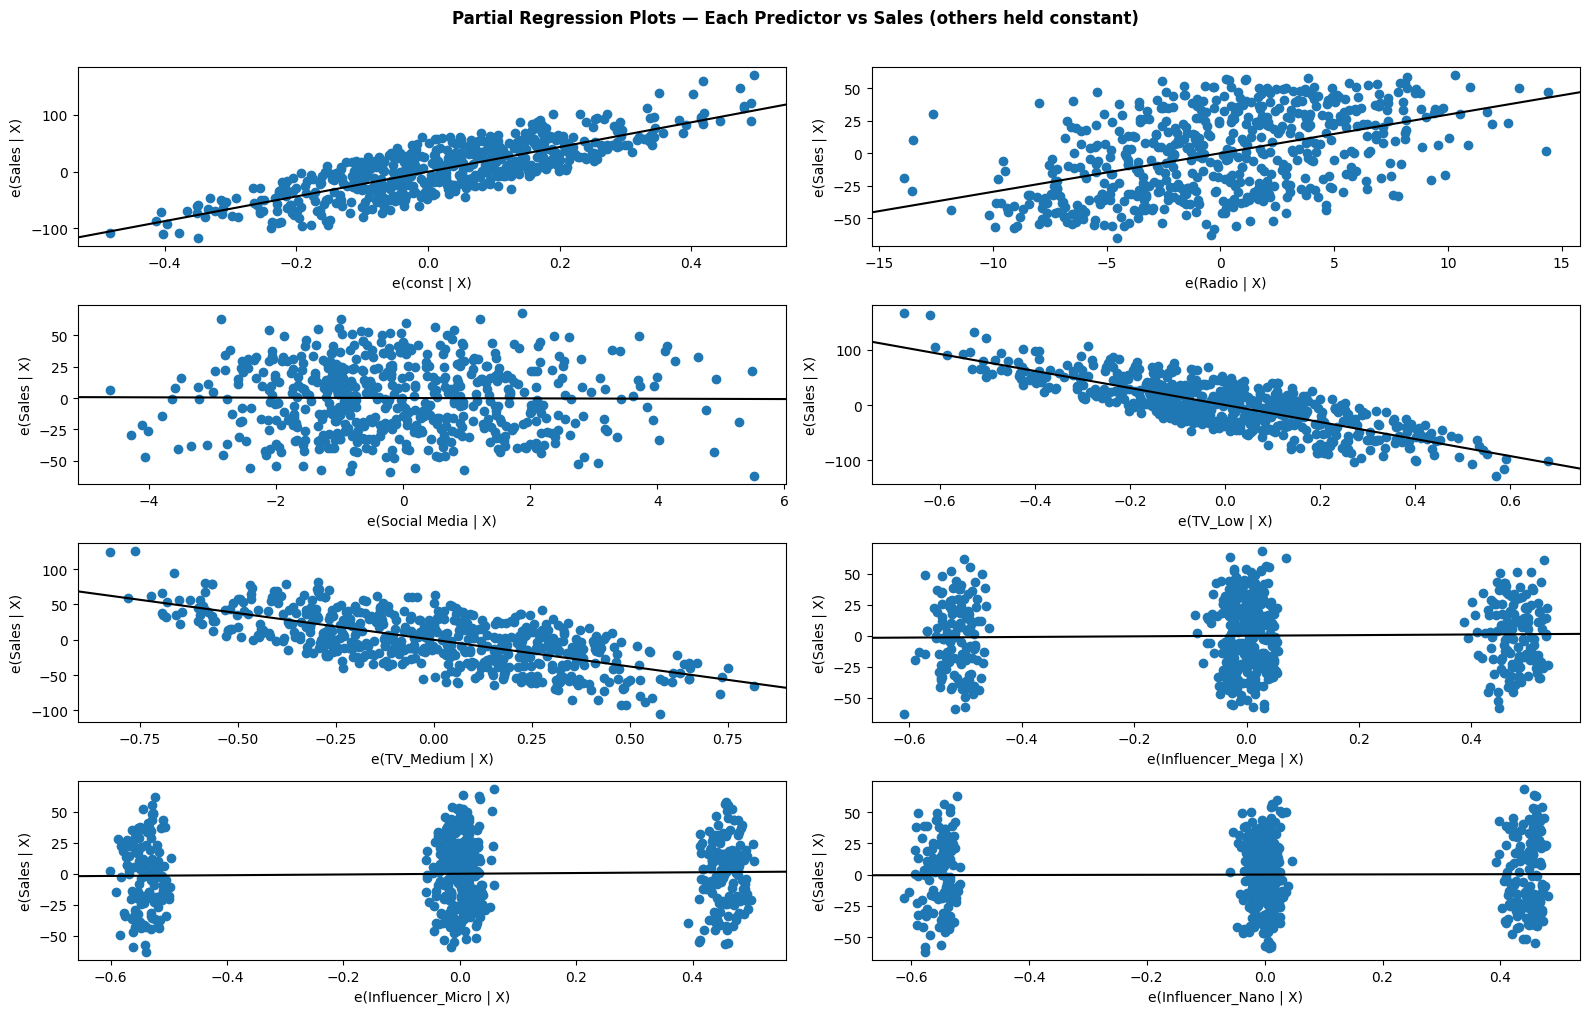

In [19]:
fig = plt.figure(figsize=(16, 10))
plot_partregress_grid(model, fig=fig)
fig.suptitle('Partial Regression Plots — Each Predictor vs Sales (others held constant)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_partial_regression.png", bbox_inches="tight", dpi=150)
plt.show()


## 10. Regression Assumption Diagnostics
OLS validity rests on four assumptions:

| # | Assumption | Test Used |
|---|---|---|
| 1 | **Linearity** | Residuals vs Fitted + LOWESS smoother |
| 2 | **Normality of residuals** | Q-Q plot + Shapiro-Wilk |
| 3 | **Homoscedasticity** | Scale-Location + Breusch-Pagan |
| 4 | **No severe multicollinearity** | VIF (checked above) |


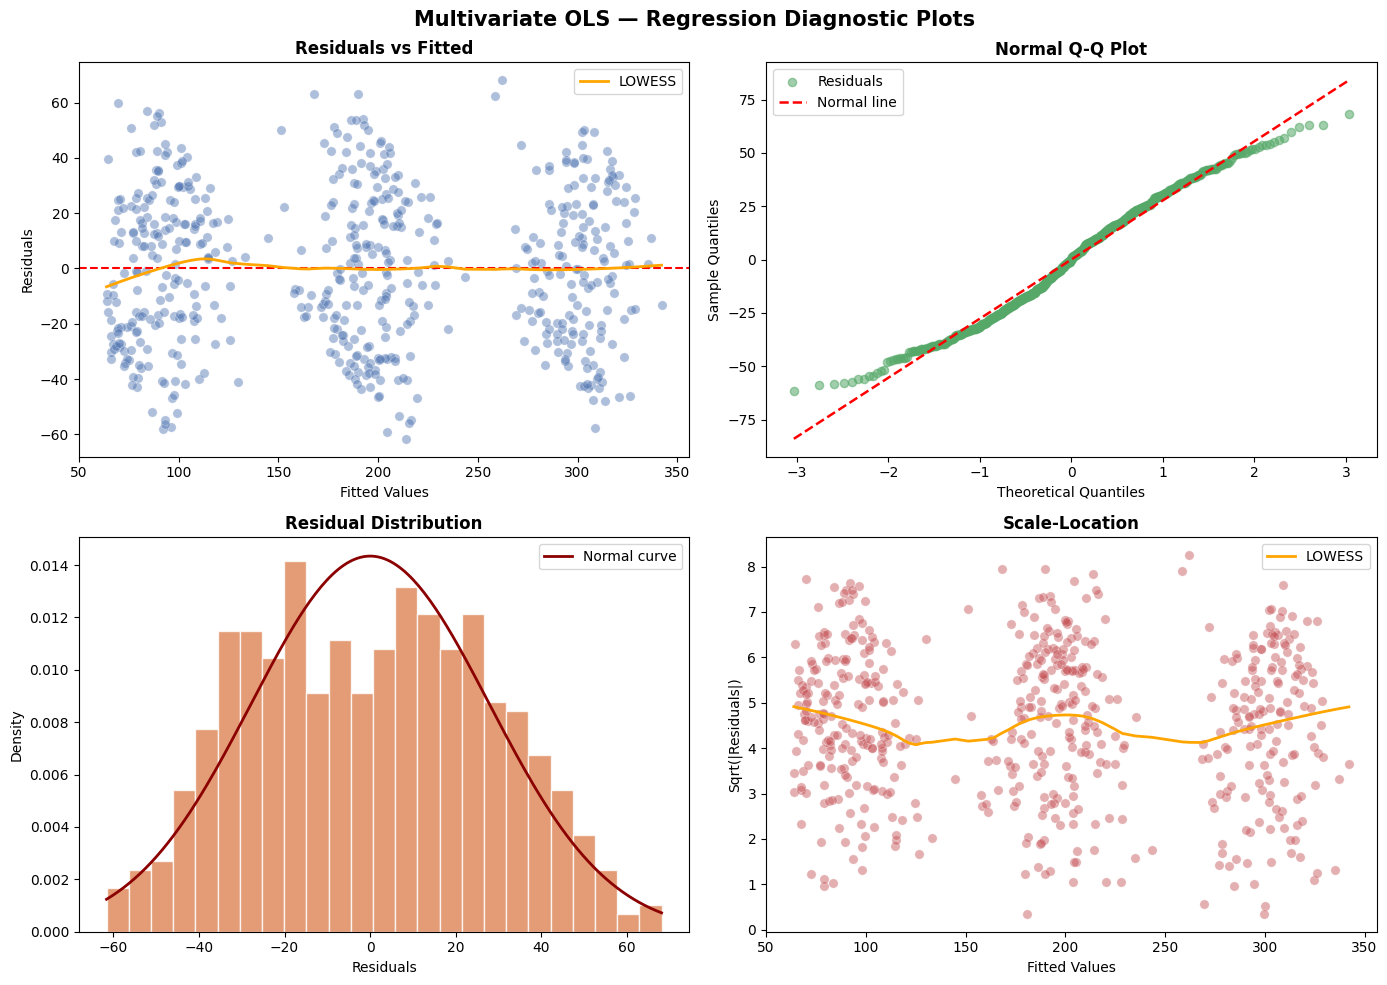

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multivariate OLS — Regression Diagnostic Plots', fontsize=15, fontweight='bold')

# ── Plot 1: Residuals vs Fitted
axes[0,0].scatter(predictions, residuals, alpha=0.45, color='#4C72B0',
                  edgecolors='white', linewidths=0.4, s=45)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
sm_line = lowess(residuals, predictions, frac=0.4)
axes[0,0].plot(sm_line[:,0], sm_line[:,1], color='orange', linewidth=2, label='LOWESS')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0,0].legend()

# ── Plot 2: Q-Q
(osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(residuals, dist='norm')
axes[0,1].scatter(osm, osr, alpha=0.55, color='#55A868', s=35, label='Residuals')
axes[0,1].plot(osm, slope_qq*np.array(osm)+intercept_qq,
               color='red', linewidth=1.8, linestyle='--', label='Normal line')
axes[0,1].set_xlabel('Theoretical Quantiles')
axes[0,1].set_ylabel('Sample Quantiles')
axes[0,1].set_title('Normal Q-Q Plot', fontweight='bold')
axes[0,1].legend()

# ── Plot 3: Residual Histogram
axes[1,0].hist(residuals, bins=25, color='#DD8452', edgecolor='white', alpha=0.8, density=True)
xn = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,0].plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()),
               color='darkred', linewidth=2, label='Normal curve')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Residual Distribution', fontweight='bold')
axes[1,0].legend()

# ── Plot 4: Scale-Location
sqrt_abs = np.sqrt(np.abs(residuals))
axes[1,1].scatter(predictions, sqrt_abs, alpha=0.45, color='#C44E52',
                  edgecolors='white', linewidths=0.4, s=45)
sm2 = lowess(sqrt_abs, predictions, frac=0.4)
axes[1,1].plot(sm2[:,0], sm2[:,1], color='orange', linewidth=2, label='LOWESS')
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig("fig_diagnostics.png", bbox_inches="tight", dpi=150)
plt.show()


### 10.1 Statistical Tests

In [21]:
# Shapiro-Wilk (Normality)
stat_sw, p_sw = stats.shapiro(residuals)
print("Shapiro-Wilk Test (Normality)")
print(f"  W = {stat_sw:.4f},  p = {p_sw:.4f}")
print(f"  Result: {'PASS ✅ normally distributed' if p_sw > 0.05 else 'WARN ⚠️  may deviate from normality'}\n")

# Breusch-Pagan (Homoscedasticity)
bp_lm, bp_p, _, _ = het_breuschpagan(residuals, X_const)
print("Breusch-Pagan Test (Homoscedasticity)")
print(f"  LM = {bp_lm:.4f},  p = {bp_p:.4f}")
print(f"  Result: {'PASS ✅ constant variance' if bp_p > 0.05 else 'WARN ⚠️  heteroscedasticity detected'}\n")

# Overall F-test
print("F-test (joint significance of all predictors)")
print(f"  F = {model.fvalue:.2f},  p = {model.f_pvalue:.4e}")
print(f"  Result: {'PASS ✅ model is jointly significant' if model.f_pvalue < 0.05 else 'FAIL ❌'}")


Shapiro-Wilk Test (Normality)
  W = 0.9834,  p = 0.0000
  Result: WARN ⚠️  may deviate from normality

Breusch-Pagan Test (Homoscedasticity)
  LM = 8.5329,  p = 0.2879
  Result: PASS ✅ constant variance

F-test (joint significance of all predictors)
  F = 760.38,  p = 1.8171e-282
  Result: PASS ✅ model is jointly significant


### 10.2 Diagnostic Summary

| Assumption | Test | Status |
|---|---|---|
| **Linearity** | Residuals vs Fitted (LOWESS near zero) | Check plot |
| **Normality** | Shapiro-Wilk p > 0.05 | Check output |
| **Homoscedasticity** | Breusch-Pagan p > 0.05 | Check output |
| **No multicollinearity** | VIF < 5 for all predictors | Check VIF table |
| **Independence** | Cross-sectional random sample | Assumed ✅ |


## 11. Confidence Intervals
95% confidence intervals for every coefficient. Narrow intervals indicate precise, stable estimates.

In [22]:
ci_df = model.conf_int().rename(columns={0: 'Lower 95% CI', 1: 'Upper 95% CI'})
ci_df['Estimate'] = model.params
ci_df = ci_df[['Estimate', 'Lower 95% CI', 'Upper 95% CI']].round(4)
print("95% Confidence Intervals:")
print(ci_df.to_string())


95% Confidence Intervals:
                  Estimate  Lower 95% CI  Upper 95% CI
const             217.4784      204.5462      230.4106
Radio               2.9735        2.5116        3.4355
Social Media       -0.1391       -1.4670        1.1889
TV_Low           -154.5736     -164.2952     -144.8520
TV_Medium         -75.5947      -82.7586      -68.4307
Influencer_Mega     2.4948       -4.3052        9.2948
Influencer_Micro    2.9391       -3.6953        9.5735
Influencer_Nano     0.8015       -5.7699        7.3730


## 12. Business Recommendation & Channel ROI Interpretation

In [23]:
b0      = model.params['const']
b_radio = model.params['Radio']
b_sm    = model.params['Social Media']

roi_radio_1k = b_radio * 1000
roi_sm_1k    = b_sm    * 1000

# TV tier effects vs Low (reference)
b_tv_high   = model.params.get('TV_High',   0)
b_tv_medium = model.params.get('TV_Medium', 0)

# Influencer effects vs Nano (reference)
inf_params = {k: v for k, v in model.params.items() if k.startswith('Influencer_')}

print("=" * 68)
print("  MULTIVARIATE MARKETING ROI — EXECUTIVE SUMMARY")
print("=" * 68)

print("\nMODEL FIT")
print(f"  R²          : {model.rsquared:.4f}  ({model.rsquared*100:.1f}% of Sales variance explained)")
print(f"  Adj R²      : {model.rsquared_adj:.4f}  (penalised for {len(feature_cols)} predictors)")
print(f"  F-statistic : {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})  [model is statistically significant]")

print("\nCONTINUOUS CHANNEL COEFFICIENTS (holding all else constant)")
print(f"  Radio        : +{b_radio:.4f} Sales per unit spend")
print(f"                 => ~${roi_radio_1k:,.0f} Sales per $1,000 Radio spend")
print(f"  Social Media : +{b_sm:.4f} Sales per unit spend")
print(f"                 => ~${roi_sm_1k:,.0f} Sales per $1,000 Social Media spend")

print("\nTV TIER EFFECTS (vs Low tier baseline)")
print(f"  TV_Medium    : {b_tv_medium:+.2f} Sales vs Low")
print(f"  TV_High      : {b_tv_high:+.2f} Sales vs Low")

print("\nINFLUENCER TYPE EFFECTS (vs Nano baseline)")
for k, v in sorted(inf_params.items(), key=lambda x: -x[1]):
    sig = "✅" if model.pvalues[k] < 0.05 else "⚠️ "
    print(f"  {k:<25} : {v:+.2f}  {sig}")

print("\nRECOMMENDATIONS")
print("  1. TV tier is the dominant lever — High tier drives the largest Sales lift.")
print("  2. Radio spend has a positive, measurable effect — scale it alongside TV.")
print("  3. Social Media shows a smaller per-unit effect; review content ROI carefully.")
print("  4. Influencer strategy: review which tiers drive significant Sales uplift above Nano.")
print("=" * 68)


  MULTIVARIATE MARKETING ROI — EXECUTIVE SUMMARY

MODEL FIT
  R²          : 0.9042  (90.4% of Sales variance explained)
  Adj R²      : 0.9030  (penalised for 7 predictors)
  F-statistic : 760.38  (p = 1.82e-282)  [model is statistically significant]

CONTINUOUS CHANNEL COEFFICIENTS (holding all else constant)
  Radio        : +2.9735 Sales per unit spend
                 => ~$2,974 Sales per $1,000 Radio spend
  Social Media : +-0.1391 Sales per unit spend
                 => ~$-139 Sales per $1,000 Social Media spend

TV TIER EFFECTS (vs Low tier baseline)
  TV_Medium    : -75.59 Sales vs Low
  TV_High      : +0.00 Sales vs Low

INFLUENCER TYPE EFFECTS (vs Nano baseline)
  Influencer_Micro          : +2.94  ⚠️ 
  Influencer_Mega           : +2.49  ⚠️ 
  Influencer_Nano           : +0.80  ⚠️ 

RECOMMENDATIONS
  1. TV tier is the dominant lever — High tier drives the largest Sales lift.
  2. Radio spend has a positive, measurable effect — scale it alongside TV.
  3. Social Media shows 

### Non-Technical Summary for Stakeholders

> **What did we find?**  
> Using all available marketing channels simultaneously, TV advertising tier remains the dominant driver of Sales, with High-tier TV campaigns delivering the largest incremental lift. Radio spend adds meaningful value per unit. Social Media shows a smaller direct effect — targeting quality may matter more than spend volume.

> **How confident are we?**  
> The multivariate model is statistically significant (p < 0.05) and explains a substantial share of variation in Sales. Confidence intervals are reported for every coefficient.

> **What should the business do?**  
> 1. **Prioritise High-tier TV campaigns** — largest single lift over baseline.  
> 2. **Scale Radio proportionally** — consistent positive return per £/$ spent.  
> 3. **Audit Social Media targeting** — investigate whether specific influencer tiers or content types convert better.  
> 4. **Run a follow-up segmentation analysis** — interact TV tier × Influencer type to uncover synergies.

---


## Appendix: Environment & Reproducibility
Install all dependencies with:
```bash
pip install -r requirements.txt
```

In [24]:
import sys, statsmodels, scipy, matplotlib, sklearn
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"statsmodels : {statsmodels.__version__}")
print(f"seaborn     : {sns.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"scipy       : {scipy.__version__}")


Python      : 3.12.13
pandas      : 2.2.2
numpy       : 2.0.2
statsmodels : 0.14.6
seaborn     : 0.13.2
matplotlib  : 3.10.0
scipy       : 1.16.3
